# Concrete Crack Image Classification

In [1]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import torchvision.datasets as dsets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

### Useful Functions

In [58]:
def show_data(ax, data_sample , IMAGE_SIZE):
    
    ax.imshow(data_sample[0].numpy().reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
    ax.set_title('y = '+ str(data_sample[1]))


# Load Data

Downloading data from IBM object storage using`skillsnetwork.prepare` command. This command is used to download a zip file, unzip it and store it in a specific directory.

In [3]:
import skillsnetwork

directory = './data/Concrete Crack Classifier Data'
await skillsnetwork.prepare("https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0321EN/data/images/concrete_crack_images_for_classification.zip", path = directory, overwrite=True)

  0%|          | 0/40000 [00:00<?, ?it/s]

Saved to 'data/Concrete Crack Classifier Data'


#### This data contains two folders
* Positive : Concrete images with crack
* Negative: Concrete images without crack


Let's grab the file path for each of these categories

In [4]:
import os

negative_file_path = os.path.join(directory,'Negative')
positive_file_path = os.path.join(directory,'Positive')


We can access each images of each category using the folder path and `os.listdir` function

In [5]:
os.listdir(negative_file_path)[0:3]

['14147.jpg', '04354.jpg', '13628.jpg']

In some cases, we may have files of a different type, so we have to ensure it's of type <b>jpg</b>. We have to check the extension using the method <code> endswith()</code>. The method  <code>endswith()</code> returns True if the string ends with the specified suffix, otherwise, it will return False. Let's do a quick example:

In [6]:
print("test.jpg".endswith(".jpg"))

True


In [7]:
negative_files=[os.path.join(negative_file_path,file) for file in  os.listdir(negative_file_path) if file.endswith(".jpg")]
negative_files.sort()
negative_files[0:3]

['./data/Concrete Crack Classifier Data/Negative/00001.jpg',
 './data/Concrete Crack Classifier Data/Negative/00002.jpg',
 './data/Concrete Crack Classifier Data/Negative/00003.jpg']

In [8]:
positive_files=[os.path.join(positive_file_path,file) for file in  os.listdir(positive_file_path) if file.endswith(".jpg")]
positive_files.sort()
positive_files[0:3]

['./data/Concrete Crack Classifier Data/Positive/00001.jpg',
 './data/Concrete Crack Classifier Data/Positive/00002.jpg',
 './data/Concrete Crack Classifier Data/Positive/00003.jpg']

# Data Visualization

We can open an image by using the <code>Image</code> Module in the  `PIL library`, using the `function open`. We only require the image path; the input is the path of the image.

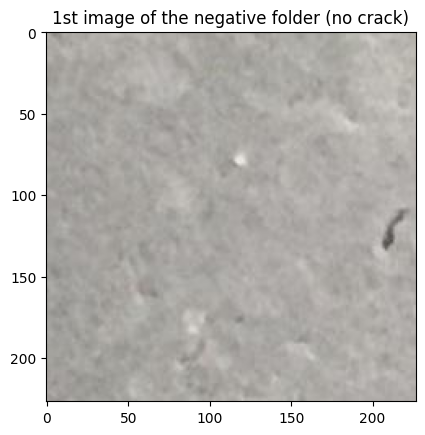

In [9]:
image_negative = Image.open(negative_files[0])
plt.imshow(image_negative)
plt.title('1st image of the negative folder (no crack)')
plt.show()

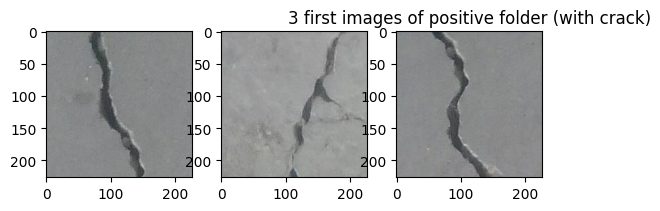

In [10]:
fig,ax = plt.subplots(1,3)
for i in range(3):
    image_positive = Image.open(positive_files[i])
    ax[i].imshow(image_positive)
plt.title('3 first images of positive folder (with crack)')
plt.show()


# Assigning Label to the Images

In [11]:
number_of_samples = len(positive_files)+len(negative_files)
print(f"Total number of samples is {number_of_samples}. {len(positive_files)} samples are with crack , and {len(negative_files)} samples are without crack")

Total number of samples is 40000. 20000 samples are with crack , and 20000 samples are without crack


We need to assign a label to each image
* Y=1,  for positive images, i.e images with a crack t
* Y=0,  for negative images i.e images with out a crack

With respect to each element we will set the even elements to class 1 and the odd elements to class 0.


In [12]:
Y = torch.zeros(number_of_samples).type(torch.LongTensor)
Y.type()

'torch.LongTensor'

In [13]:
Y[::2] = 1
Y[1::2] = 0

Now, we need to crate a list of all samples, with respect to the labels Y:
* Even indices should contain the path to positive images
* Odd indices should contain the path to negative images

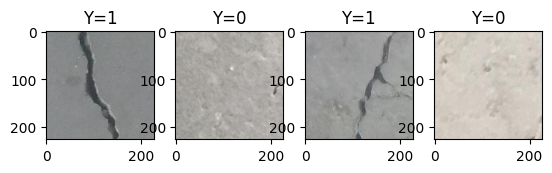

In [14]:
all_files = [None]*number_of_samples
all_files[::2] = positive_files
all_files[1::2] = negative_files

fig,ax = plt.subplots(1,4)
n = 0
for y,file in zip(Y,all_files[0:4]):
    ax[n].imshow(Image.open(file))
    ax[n].set_title(f"Y={y}")
    n += 1
plt.show()

# Create Data Module: (Load data , Label data , Apply transforms , Split train-validation data)

Create a data class:
* Even samples: positive
* Odd samples: negative
* Apply transforms, if needed
* If `train==True`: use the first 30000 data fro training and the rest for validation

In [15]:
class Datasets(Dataset):
    #Constructor
    def __init__(self, transform = None , train=True):
        #---------------------load images
        directory = './data/Concrete Crack Classifier Data/'
        positive = "Positive"
        negative = "Negative"

        positive_file_path = os.path.join(directory,positive)
        negative_file_path = os.path.join(directory,negative)
        positive_files = [os.path.join(positive_file_path,file) for file in os.listdir(positive_file_path) if file.endswith(".jpg")]
        positive_files.sort()
        negative_files = [os.path.join(negative_file_path,file) for file in os.listdir(negative_file_path) if file.endswith(".jpg")]
        negative_files.sort()
        
        number_of_samples = len(positive_files) + len(negative_files)
        
        self.all_files = [None]*number_of_samples
        self.all_files[::2] = positive_files
        self.all_files[1::2] = negative_files
        #---------------------label images
        self.Y = torch.zeros([number_of_samples]).type(torch.LongTensor)
        self.Y[::2] = 1
        self.Y[1::2] = 0
        #---------------------split training and validation data
        if train :
            self.all_files = self.all_files[:30000]
            self.Y = self.Y[:30000]
            self.len = len(self.all_files)
        else:
            self.all_files = self.all_files[30000:]
            self.Y = self.Y[3000:]
            self.len = len(self.all_files)

        self.transform = transform
            
    #Get the length
    def __len__(self):
        return self.len

    #Getter
    def __getitem__(self,index):
        image = Image.open(self.all_files[index])
        y = self.Y[index]
        #---------------------apply transforms
        if self.transform :
            image = self.transform(image)
        return image,y

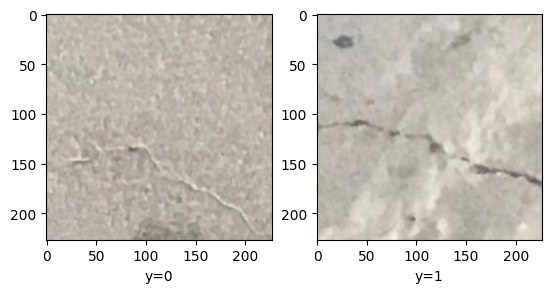

In [16]:
#Observing training dataset
train_dataset = Datasets(train=True)
samples = [9,100]
fig,ax = plt.subplots(1, len(samples))
for i,sample  in enumerate(samples):
    ax[i].imshow(train_dataset[sample][0])
    ax[i].set_xlabel("y="+str(train_dataset[sample][1].item()))
    # plt.title("training data, sample {}".format(int(sample)))
plt.show()

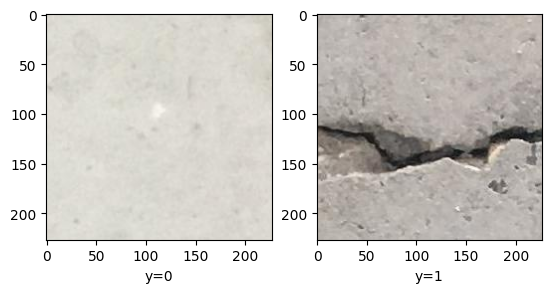

In [17]:
#Observing validation dataset
validation_dataset = Datasets(train=False)
dataset_val = Dataset()
samples = [15,102]
fig,ax = plt.subplots(1, len(samples))
for i,sample  in enumerate(samples):
    ax[i].imshow(validation_dataset[sample][0])
    ax[i].set_xlabel("y="+str(validation_dataset[sample][1].item()))
    # plt.title("training data, sample {}".format(int(sample)))
plt.show()

## Create training and validation datasets and data loaders

In [32]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
IMAGE_SIZE=227

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])
train_dataset = Datasets( transform=transform, train=True)
validation_dataset = Datasets(transform=transform, train=False)

len(train_dataset)

train_loader = DataLoader(dataset=train_dataset , batch_size = 5 , shuffle= True)
validation_loader = DataLoader(dataset=validation_dataset , batch_size = 5)

# Train Linear Classifier (Softmax)

## Create Costum Softmax module

* The input size would be size of image `227*227*3` [images are colored- 3channels]
* The output size is 2

In [33]:
class SoftMax(nn.Module):
    #constructor
    def __init__(self, layers):
        super(SoftMax,self).__init__()
        self.hidden = nn.ModuleList()
        for input_size,output_size in zip(layers,layers[1:]):
            self.hidden.append(nn.Linear(input_size,output_size))

    #predictor
    def forward(self,x):
        L = len(self.hidden)
        for l, linear_transform in zip(range(L),self.hidden):
            if l<L-1 : #hidden layers
                x = torch.relu(linear_transform(x))
            else: #output layer
                x = linear_transform(x)
        return x

#initialize the model
input_dim= 227*227*3
output_dim = 2
model = SoftMax([input_dim,output_dim])

## Define the training parameters

* Loss function: Cross Entropy
* Optimizer: Stochastic Gradient Descent
* Learning rate: 0.1
* Momentum: 0.1
* Number of Epochs : 5

In [34]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
momentum = 0.1
optimizer = optim.SGD(model.parameters(), lr= learning_rate, momentum=momentum)
Epoch_numbers = 5

training_lossess=[]
validation_lossess=[]
validation_accuracy = []
validation_size  = validation_dataset.len

#training the model
for epoch in range(Epoch_numbers):
    model.train()
    train_loss = 0
    for x,y in train_loader:
        predict = model(x.view(-1,input_dim))
        loss = criterion(predict, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    training_lossess.append(train_loss)

    model.eval()
    val_loss = 0
    correct = 0
    for x,y in validation_loader:
        predict = model(x.view(-1,input_dim))
        loss = criterion(predict,y)
        val_loss += loss.item()
        _,yhat = torch.max(predict.data,1)
        correct += (yhat==y).sum().item()
    validation_accuracy.append(100*correct / validation_size)
    validation_lossess.append(val_loss)

    print(f"for epoch {epoch}, training loss is {train_loss}, validation loss is {val_loss}, and validation accuracy is {100*correct / validation_size} ")
        

for epoch 0, training loss is 6820618.514793212, validation loss is 1937165.2656009197, and validation accuracy is 84.58 
for epoch 1, training loss is 5502092.115131911, validation loss is 2069116.9182595848, and validation accuracy is 84.39 
for epoch 2, training loss is 5016607.354993198, validation loss is 4525384.796328306, and validation accuracy is 76.4 
for epoch 3, training loss is 4886762.747997158, validation loss is 7028032.426168776, and validation accuracy is 71.23 
for epoch 4, training loss is 4785098.526633851, validation loss is 1952973.1478632218, and validation accuracy is 85.09 


Text(0, 0.5, 'Validation Accuracy (%)')

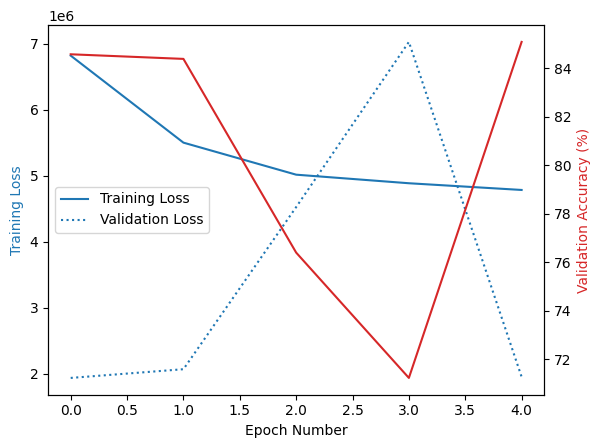

In [35]:
fig,ax = plt.subplots()
color = "tab:blue"
ax.plot(training_lossess, color=color,label='Training Loss')
ax.plot(validation_lossess, ':',color=color,label='Validation Loss')
ax.legend()
ax.set_ylabel("Training Loss",color=color)
ax.set_xlabel("Epoch Number")

ax2 = ax.twinx()
color = "tab:red"
ax2.plot(validation_accuracy,color=color)
ax2.set_ylabel("Validation Accuracy (%)",color=color)

# Resnet18: Pretrained Model



 For epoch number 1, training loss is 0.08562370399944484, and validation accuracy is 98.97


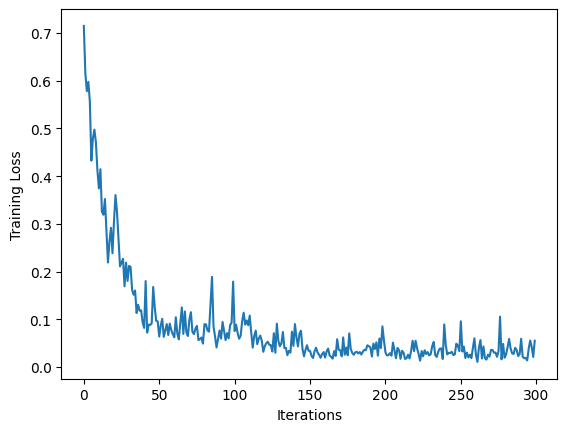

In [45]:
##To resolve the errors due to Resnet model loading
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from torchvision import models

#import pretrained resnet18 model 
model = models.resnet18(pretrained=True)

#set the grad atribute of the parameters for resnet model `False`, so the pretrained parameters don't change
for param in model.parameters():
    param.requires_grad=False

#Create transform object
composed = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])

#Create dataset objects
train_dataset = Datasets( transform=composed, train=True)
validation_dataset = Datasets(transform=composed, train=False)


train_loader = DataLoader(dataset=train_dataset , batch_size = 100)
validation_loader = DataLoader(dataset=validation_dataset , batch_size = 100)

# Replace the output layer of Resnet NN with linear layer using "model.fc" attribute
#Last layer of Resnet has 512 neurons - you can find the neuron numbers by printing model state_dict()
model.fc=nn.Linear(512,2)

# Create Loss function 
criterion = nn.CrossEntropyLoss()

#create optimizer object
#imp: Apply optimization function ONLY to the parameters of last layer with requires_grad=True (not resnet parameters)
learning_rate=0.001
optimizer = optim.Adam([parameters for parameters in model.parameters() if parameters.requires_grad] , lr=learning_rate)

#Training parameters
number_of_epochs=1
loss_list=[]
accuracy_list=[]
correct=0
n_test=len(validation_dataset)
# start_time = time.time()

#Train the model
for epoch in range(number_of_epochs):
    model.train()
    loss_sublist=[]
    for x,y in train_loader:
        predict = model(x)
        optimizer.zero_grad()
        loss = criterion(predict,y)
        loss.backward()
        optimizer.step()
        loss_sublist.append(loss.item())
    loss_list.append(np.mean(loss_sublist))

    model.eval()
    correct=0
    for x,y in validation_loader:
        predict = model(x)
        _,yhat = torch.max(predict.data,1)
        correct+= (yhat==y).sum().item()
    accuracy_list.append(100*correct/n_test)
    print(f" For epoch number {epoch+1}, training loss is {loss_list[epoch]}, and validation accuracy is {accuracy_list[epoch]}")

#Plot training loss
fig,ax = plt.subplots()
ax.plot(loss_sublist)
ax.set_ylabel("Training Loss")
ax.set_xlabel("Iterations")
plt.show()


In [91]:
num_misclassified = 4
n = 0
for i, sample in enumerate(validation_dataset):
    predict = model(sample[0].reshape([1,3,224,224]))
    _,yhat = torch.max(predict.data,1)
    if (yhat.item()!=sample[1]) :
        print(f"Sample {i}, Predicted value is {yhat.item()}, Actual value is {sample[1]}")
        n +=1
    if n==num_misclassified :
        break
    

Sample 94, Predicted value is 0, Actual value is 1
Sample 142, Predicted value is 0, Actual value is 1
Sample 452, Predicted value is 0, Actual value is 1
Sample 652, Predicted value is 0, Actual value is 1
